# BMI Calculator
Workflow
> START ---> Calculate BMI ---> END 

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

Define State

In [4]:
# we use python classes for state
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float

Define Graph

In [5]:
# always use StateGraph for graphs in langgraph and pass state to it;
graph = StateGraph(BMIState)

In [6]:
# pass state and return state
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight']
    height = state['height']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi, 2)
    return state

Add Nodes to Graph

In [9]:
# graph.add_node('any name just like variable for it', python function_name)
graph.add_node('calculate_bmi', calculate_bmi)

Add Edges in Graph

In [10]:
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)

Compile the Graph

In [11]:
workflow = graph.compile()

Execute the Graph

In [14]:
initial_state = {'weight': 56, 'height': 5.11}
final_state = workflow.invoke(initial_state)

In [15]:
print(final_state)

{'weight': 56, 'height': 5.11, 'bmi': 2.14}


Display graph

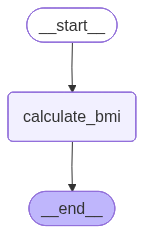

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# LLM Workflow
Workflow
> START ---> LLM ---> END

In [17]:
from langgraph.graph import StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [19]:
load_dotenv()

True

In [ ]:
model = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
)

State

In [22]:
class LLMState(TypedDict):
    question: str
    answer: str

In [23]:
def llmqa(state: LLMState) -> LLMState:
    question = state['question']
    # form a prompt
    prompt = f'Answer the following Question \n *QUESTION*: {question}'

    answer = model.invoke(question).content[0]['text']
    state['answer'] = answer
    return state

Graph

In [25]:
graph = StateGraph(LLMState)

# creating node
graph.add_node('llmqa', llmqa)

# creating edges
graph.add_edge(START, 'llmqa')
graph.add_edge('llmqa', END)

# compile graph
workflow = graph.compile()

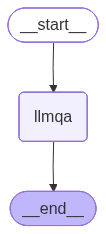

In [26]:
workflow

In [27]:
initial_state = {'question': 'What are the future technologies of AI?'}
final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'What are the future technologies of AI?', 'answer': 'The future of Artificial Intelligence is moving away from simple "chatbots" toward systems that are autonomous, physically embodied, and capable of human-like reasoning.\n\nHere are the key future technologies and paradigms shaping the next decade of AI:\n\n### 1. Agentic AI (Autonomous Agents)\nCurrent AI is mostly reactive (you give a prompt, it gives an answer). The next phase is **Agentic AI**—systems that can set their own goals, use tools, and execute multi-step tasks without human supervision.\n*   **The Tech:** AI "Agents" that can browse the web, manage your email, write and execute code, and handle complex workflows (e.g., "Research this market, create a business plan, and set up the website").\n*   **Impact:** A shift from AI as a consultant to AI as a digital employee.\n\n### 2. Embodied AI (Humanoid Robotics)\nAI is moving out of the screen and into the physical world. This is the intersection of Large Lang

In [28]:
final_state['answer']

'The future of Artificial Intelligence is moving away from simple "chatbots" toward systems that are autonomous, physically embodied, and capable of human-like reasoning.\n\nHere are the key future technologies and paradigms shaping the next decade of AI:\n\n### 1. Agentic AI (Autonomous Agents)\nCurrent AI is mostly reactive (you give a prompt, it gives an answer). The next phase is **Agentic AI**—systems that can set their own goals, use tools, and execute multi-step tasks without human supervision.\n*   **The Tech:** AI "Agents" that can browse the web, manage your email, write and execute code, and handle complex workflows (e.g., "Research this market, create a business plan, and set up the website").\n*   **Impact:** A shift from AI as a consultant to AI as a digital employee.\n\n### 2. Embodied AI (Humanoid Robotics)\nAI is moving out of the screen and into the physical world. This is the intersection of Large Language Models (LLMs) and robotics.\n*   **The Tech:** Using "Foundat

# Complex Linear Workflow of LLM

Wokrflow architecture

> Topic -> Outline Generator -> Section Writer -> SEO Optimizer -> Final Proofread


In [29]:
class BlogWritingState(TypedDict):
    topic: str
    outline: str
    sections: str
    seo_content: str
    final_article: str

In [38]:
def outlineGenerator(state: BlogWritingState) -> BlogWritingState:
    topic = state['topic']
    prompt = f"""You are a professional content strategist.

TASK:
Create a clear, well-structured blog outline for the following topic.

TOPIC:
{topic}

REQUIREMENTS:
- Use H1 for title, H2 for main sections, H3 for subsections if needed
- Keep it informative and reader-friendly
- Optimize structure for SEO (logical flow, keyword-friendly headings)
- Do NOT write full paragraphs, only headings and bullet points

OUTPUT FORMAT:
Title: <H1 title>

Outline:
- H2: ...
  - H3: ...
- H2: ...
"""
    outline = model.invoke(prompt)
    state['outline'] = outline.content[0]['text']
    return state

In [50]:
def sectionWriter(state: BlogWritingState) -> BlogWritingState:
    topic = state['topic']
    outline = state['outline']
    prompt = f"""You are an expert blog writer.

TASK:
Write detailed, engaging content for each section in the outline below.

TOPIC:
{topic}

OUTLINE:
{outline}

WRITING GUIDELINES:
- Write in a natural, professional tone
- Each H2 should have 1–3 well-developed paragraphs
- Use simple language and clear explanations
- Include examples where helpful
- Avoid keyword stuffing

OUTPUT FORMAT:
Return the full article with proper headings (H1, H2, H3).
"""
    sections = model.invoke(prompt)
    state['sections'] = sections.content[0]['text']
    return state

In [51]:
def seoOptimizer(state: BlogWritingState) -> BlogWritingState:
    sections = state['sections']
    prompt = f"""You are an SEO optimization expert.

TASK:
Optimize the following blog content for search engines while preserving clarity and originality.

INPUT CONTENT:
{sections}

SEO REQUIREMENTS:
- Improve keyword placement naturally
- Optimize headings for search intent
- Add internal-style linking phrases (no URLs)
- Improve meta readability (but do NOT add a meta description)
- Maintain human-like writing

IMPORTANT:
- Do NOT change the structure
- Do NOT remove any sections
- Do NOT add new sections

OUTPUT:
Return the SEO-optimized article.
"""
    seo_content = model.invoke(prompt)
    state['seo_content'] = seo_content.content[0]['text']
    return state

In [52]:
def finalProofReader(state: BlogWritingState) -> BlogWritingState:
    seo_content = state['seo_content']
    prompt = f"""You are a senior editor and proofreader.

TASK:
Proofread and refine the following article to make it publication-ready.

INPUT ARTICLE:
{seo_content}

CHECK FOR:
- Grammar and spelling errors
- Sentence flow and readability
- Redundancy and awkward phrasing
- Consistent tone

RULES:
- Do NOT change meaning
- Do NOT add new information
- Do NOT remove headings

OUTPUT:
Return the final polished article only.
"""
    final_article = model.invoke(prompt)
    state['final_article'] = final_article.content[0]['text']
    return state

In [53]:
graph = StateGraph(BlogWritingState)

# creating nodes
graph.add_node('outline_generator', outlineGenerator)
graph.add_node('section_writer', sectionWriter)
graph.add_node('seo_optimizer', seoOptimizer)
graph.add_node('final_proof_reader', finalProofReader)


# creating edges
graph.add_edge(START, 'outline_generator')
graph.add_edge('outline_generator', 'section_writer')
graph.add_edge('section_writer', 'seo_optimizer')
graph.add_edge('seo_optimizer', 'final_proof_reader')
graph.add_edge('final_proof_reader', END)


# compiling graph
workflow = graph.compile()


In [54]:
initial_state = {'topic': 'Convolutional Neural Network Architecture'}
final_state = workflow.invoke(initial_state)

In [55]:
print(final_state['outline'])

Title: # Understanding Convolutional Neural Network (CNN) Architecture: A Comprehensive Guide

Outline:

- ## Introduction to Convolutional Neural Networks (CNNs)
  - ### What is a CNN?
    - Definition of CNNs as deep learning algorithms for processing grid-like data.
    - The primary role of CNNs in computer vision and image recognition.
  - ### Why CNNs Surpass Traditional Neural Networks
    - Limitations of Multi-Layer Perceptrons (MLPs) with high-dimensional image data.
    - Concept of spatial hierarchy and pattern recognition.

- ## The Core Building Blocks of CNN Architecture
  - ### The Convolutional Layer (The Heart of the CNN)
    - Function of filters (kernels) in feature extraction.
    - How feature maps are generated.
  - ### The Activation Function (ReLU)
    - Introducing non-linearity into the model.
    - Why ReLU (Rectified Linear Unit) is the industry standard for CNNs.
  - ### The Pooling Layer (Downsampling)
    - Reducing spatial dimensions to decrease computa

In [56]:
print(final_state['sections'])

# Understanding Convolutional Neural Network (CNN) Architecture: A Comprehensive Guide

In the realm of Artificial Intelligence, few innovations have been as transformative as the Convolutional Neural Network (CNN). By mimicking the way the human visual cortex processes information, CNNs have revolutionized how machines "see" and interpret the world. Whether it is a smartphone unlocking via facial recognition or a self-driving car identifying a pedestrian, the underlying engine is almost certainly a CNN.

## Introduction to Convolutional Neural Networks (CNNs)

### What is a CNN?
A Convolutional Neural Network (CNN) is a specialized type of deep learning algorithm designed primarily to process grid-like data structures, most notably images. Unlike standard neural networks that treat an image as a flat list of pixels, a CNN preserves the spatial relationship between pixels. This allows the network to understand that a group of pixels forms an edge, a shape, and eventually, a complex obj

In [ ]:
print(final_state['seo_content'])

# Convolutional Neural Network (CNN) Architecture: The Ultimate Guide to Deep Learning for Computer Vision

In the rapidly evolving landscape of **Artificial Intelligence**, few innovations have been as transformative as the **Convolutional Neural Network (CNN)**. By mimicking the biological processes of the human visual cortex, CNNs have revolutionized how machines "see," interpret, and categorize the world around them. Whether it is a smartphone unlocking via facial recognition or a self-driving car identifying a pedestrian in real-time, the underlying engine is almost certainly a robust **CNN architecture**.

## Introduction to Convolutional Neural Networks (CNNs): How AI Sees

### What is a CNN? Definition and Basics
A **Convolutional Neural Network (CNN)** is a specialized type of **deep learning algorithm** designed primarily to process grid-like data structures, most notably digital images. Unlike standard neural networks that treat an image as a flat list of pixels—losing vital

In [58]:
print(final_state['final_article'])


# Convolutional Neural Network (CNN) Architecture: The Ultimate Guide to Deep Learning for Computer Vision

In the rapidly evolving landscape of **Artificial Intelligence**, few innovations have been as transformative as the **Convolutional Neural Network (CNN)**. By mimicking the biological processes of the human visual cortex, CNNs have revolutionized how machines interpret and categorize the visual world. Whether it is a smartphone unlocking via facial recognition or a self-driving car identifying a pedestrian in real-time, the underlying engine is almost certainly a robust **CNN architecture**.

## Introduction to Convolutional Neural Networks (CNNs): How AI Sees

### What is a CNN? Definition and Basics
A **Convolutional Neural Network (CNN)** is a specialized **deep learning algorithm** designed primarily to process grid-like data structures, such as digital images. Unlike standard neural networks that treat an image as a flat list of pixels—thereby losing vital context—a CNN pre